In [1]:
# 1. Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. Load the dataset
df = pd.read_csv(r'C:\Users\ajasl\OneDrive\Documents\Project\OIBSIP\Task_2\ifood_df.csv')

In [3]:
# 3. Print out the Descriptive Statistics
print("Descriptive Statistics for Customer Demographics & Spending:")
# Selecting a few key columns to keep the table readable
display(df[['Income', 'Age', 'MntTotal', 'NumDealsPurchases', 'NumWebPurchases', 'NumStorePurchases']].describe())

Descriptive Statistics for Customer Demographics & Spending:


,Income,Age,MntTotal,NumDealsPurchases,NumWebPurchases,NumStorePurchases
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,51622.094785,51.095692,562.764626,2.318367,4.100680,5.823583
std,20713.063826,11.705801,575.936911,1.886107,2.737424,3.241796
min,1730.000000,24.000000,4.000000,0.000000,0.000000,0.000000
25%,35196.000000,43.000000,56.000000,1.000000,2.000000,3.000000
50%,51287.000000,50.000000,343.000000,2.000000,4.000000,5.000000
75%,68281.000000,61.000000,964.000000,3.000000,6.000000,8.000000
max,113734.000000,80.000000,2491.000000,15.000000,27.000000,13.000000


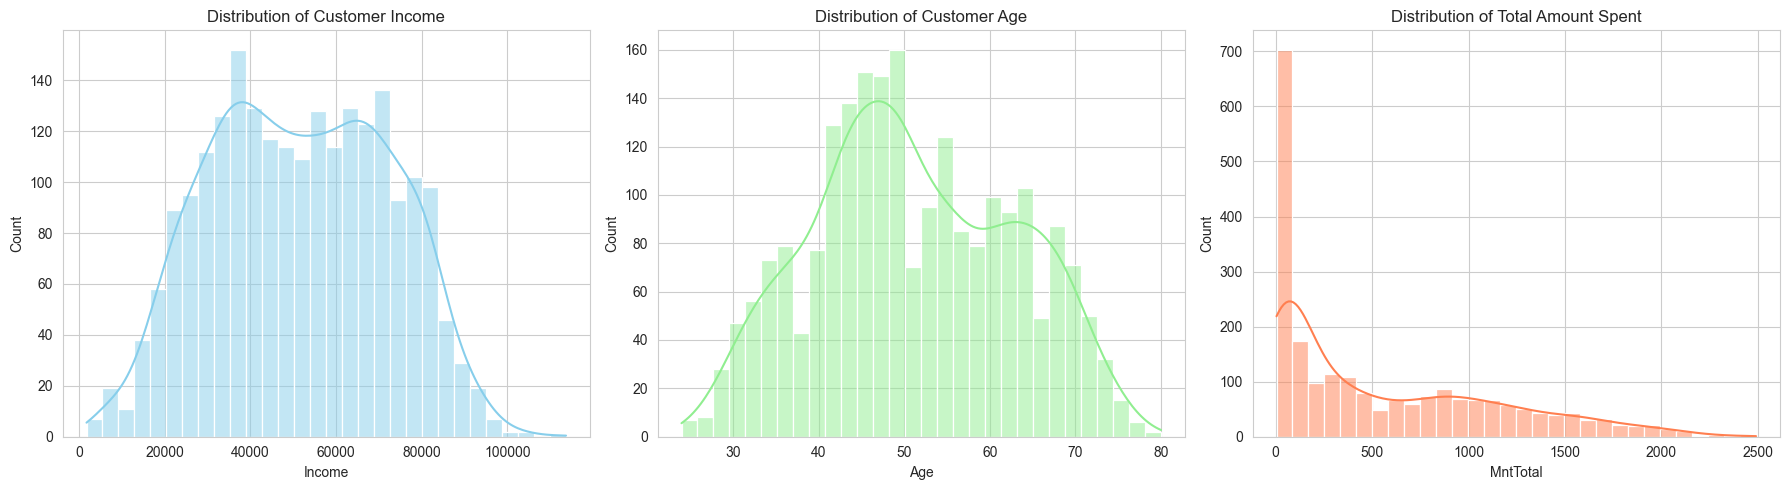

In [6]:
# 4. Visualize the Distributions
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Income Distribution
sns.histplot(df['Income'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Customer Income')

# Age Distribution
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Customer Age')

# Total Spending Distribution
sns.histplot(df['MntTotal'], bins=30, kde=True, ax=axes[2], color='coral')
axes[2].set_title('Distribution of Total Amount Spent')

plt.tight_layout()
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

# 1. Select the features we want to use for clustering
features = ['Income', 'MntTotal', 'NumWebPurchases', 'NumStorePurchases']
X = df[features]

In [8]:
# 2. Initialize the StandardScaler
scaler = StandardScaler()

In [9]:
# 3. Fit and transform the data
X_scaled = scaler.fit_transform(X)

In [11]:
# 4. Convert back to a DataFrame just to see what it looks like
df_scaled = pd.DataFrame(X_scaled, columns=features)

print("Here is what the scaled data looks like (notice the numbers are much smaller now):")
display(df_scaled.head())

Here is what the scaled data looks like (notice the numbers are much smaller now):


,Income,MntTotal,NumWebPurchases,NumStorePurchases
0,0.314651,1.678056,1.424772,-0.562650
1,-0.254877,-0.940880,-1.132957,-1.179732
2,0.965354,0.297384,1.424772,1.288596
3,-1.206087,-0.893989,-0.767567,-0.562650
4,0.322136,-0.270516,0.328602,0.054432


In [12]:
from sklearn.cluster import KMeans

# 1. Create an empty list to store the error scores (inertia)
inertia = []
K_range = range(1, 11) # We will test having 1 through 10 clusters

In [13]:
# 2. Run a loop to test K-Means for every number in our range
for k in K_range:
    # random_state ensures we get the exact same results every time we run it
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

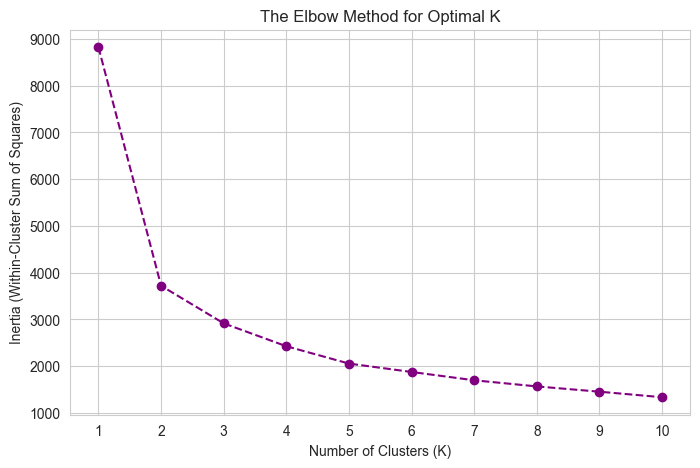

In [14]:
# 3. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='purple')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.show()

In [16]:
# 1. Apply K-Means with our chosen number of clusters (4)
kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=10)

In [17]:
# 2. Fit the model and generate the cluster labels for each customer
cluster_labels = kmeans_model.fit_predict(X_scaled)

In [18]:
# 3. Attach these new labels to our ORIGINAL (unscaled) dataframe
df['Customer_Segment'] = cluster_labels

In [19]:
# 4. See how many customers ended up in each segment!
print("Number of customers in each segment:")
print(df['Customer_Segment'].value_counts().sort_index())

Number of customers in each segment:
Customer_Segment
0    476
1    894
2    381
3    454
Name: count, dtype: int64


In [20]:
# 5. Let's look at the averages for each segment to see how they differ
print("\nAverage Demographics & Spending per Segment:")
display(df.groupby('Customer_Segment')[features].mean().round(2))


Average Demographics & Spending per Segment:


,Income,MntTotal,NumWebPurchases,NumStorePurchases
Customer_Segment,,,,
0,52950.38,413.24,4.98,5.79
1,32223.71,61.99,1.81,2.98
2,65117.99,954.32,8.18,9.20
3,77102.16,1377.04,4.27,8.63


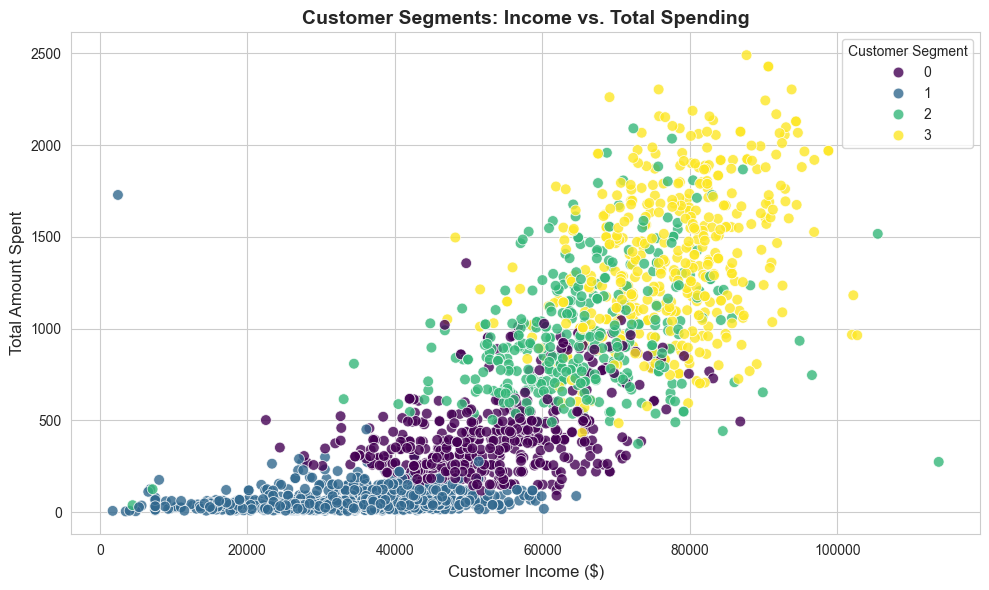

In [24]:
# Create the figure, plot the data, and add labels ALL IN ONE CELL
plt.figure(figsize=(10, 6))

# Plot the scatter plot
sns.scatterplot(x='Income', y='MntTotal', hue='Customer_Segment', data=df, palette='viridis', alpha=0.8, s=60)

# Add all the titles and labels
plt.title('Customer Segments: Income vs. Total Spending', fontsize=14, fontweight='bold')
plt.xlabel('Customer Income ($)', fontsize=12)
plt.ylabel('Total Amount Spent', fontsize=12)
plt.legend(title='Customer Segment')

# Show the final complete plot
plt.tight_layout()
plt.show()